In [15]:
from dual_spls import simulate
from dual_spls import lasso
import numpy as np

def test_d_spls_lasso_works():
    # 1. Setup
    n, p = 100, 50
    data = simulate.simulate(n=n, p=[p], nondes=[20], sigmaondes=[0.5], sigma_y=1.) # tes params
    X, y = data["X"], data["y"]

    y_col = y.reshape(-1, 1) 
    
    # 2. Run
    ncp = 10
    ppnu = 0.9 # Il faudra comprendre à quoi ça correspond dans l'algo maths
    model = lasso.dual_spls_lasso(X, y, n_components=ncp, ppnu=ppnu)
    
    # 3. Check (Ce que tu feras quand tu auras codé l'algo)
    assert model["Bhat"].shape == (p, ncp)
    assert np.allclose(model["residuals"], y_col - model["fitted_values"])

    print(y_col, model["fitted_values"])
    print(y_col - model["fitted_values"])


test_d_spls_lasso_works()

[[1025.14920684]
 [1322.63588638]
 [1312.53646808]
 [1374.11434255]
 [1204.14596468]
 [1198.36094782]
 [1123.73095462]
 [1209.99311961]
 [1380.32625809]
 [1206.99675965]
 [1107.71426914]
 [1174.50488639]
 [1593.80106369]
 [1251.16427049]
 [1180.89193247]
 [1312.78997983]
 [ 958.33188184]
 [1284.24116399]
 [1304.3073562 ]
 [ 778.71797269]
 [1334.38027948]
 [1406.51189017]
 [1493.87214804]
 [1577.98536009]
 [1044.88273309]
 [1074.08945637]
 [1374.96084342]
 [1076.42480485]
 [1164.32952101]
 [1285.82102383]
 [1138.32042286]
 [1426.71010583]
 [1224.75087522]
 [ 903.06736338]
 [1420.60112979]
 [1073.73277357]
 [1521.37775211]
 [1033.05050753]
 [1160.95983023]
 [1312.3631351 ]
 [1163.04014424]
 [1086.97843673]
 [1148.42880559]
 [1242.72361278]
 [ 938.03499741]
 [1330.65857871]
 [ 989.94714894]
 [1325.3138009 ]
 [1464.82394711]
 [1250.92210872]
 [1062.79193297]
 [1034.40705023]
 [1015.93176654]
 [1030.55949703]
 [ 887.07906285]
 [1133.57858923]
 [1232.86506536]
 [1234.04544973]
 [1291.3809126

Running Standard PLS...
Running Lasso...


/opt/miniconda3/envs/python311/lib/python3.11/site-packages/sklearn/cross_decomposition/_pls.py:507: FutureWarning: The attribute `coef_` will be transposed in version 1.3 to be consistent with other linear models in scikit-learn. Currently, `coef_` has a shape of (n_features, n_targets) and in the future it will have a shape of (n_targets, n_features).
  warnings.warn(


Running Dual-sPLS...


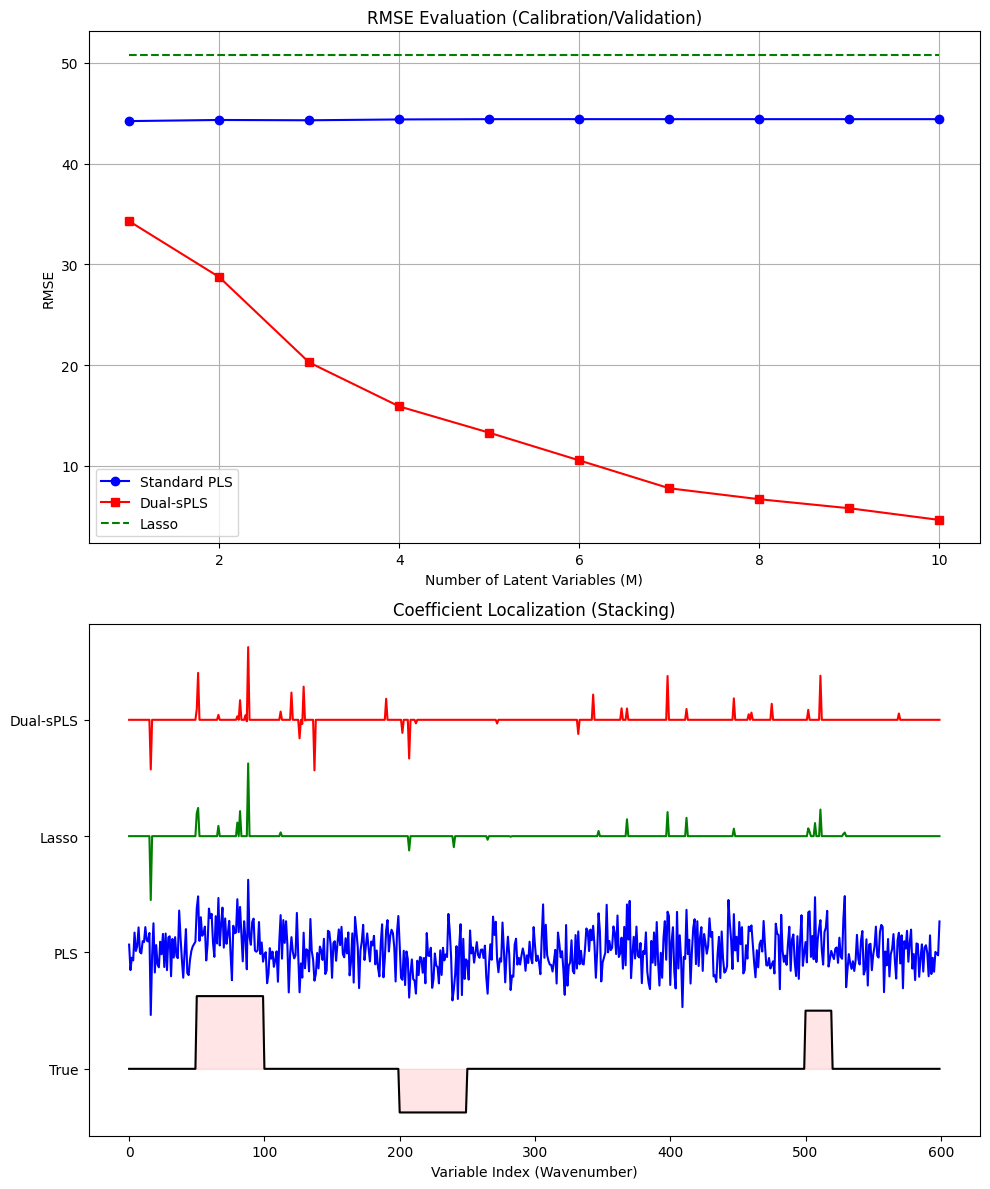


--- Analyse de la Sparsité (L0 Norm) ---
Nombre de variables sélectionnées (sur 600) :
PLS Standard : 600 (Devrait être 600, pas de sélection)
Lasso        : 24 (Sélectionne, mais parfois instable)
Dual-sPLS    : 34 (Devrait être autour de 6.000000000000005, donc faible)


In [21]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.cross_decomposition import PLSRegression
from sklearn.linear_model import LassoCV
from sklearn.metrics import mean_squared_error
from sklearn.model_selection import train_test_split
import dual_spls

# ==========================================
# 1. SETUP DE LA SIMULATION (Type DSIM)
# ==========================================
# Pour avoir des résultats "spectres" comme l'article, il faut p grand.
n = 100
p = 600   # Augmenté pour ressembler à un spectre
# On simule 3 zones actives (peaks) comme décrit souvent dans ces papiers
# Tu utiliseras ton simulateur ici. J'imagine les sorties X et y.
# data = d_spls_simulate(n=n, p=p, ...) 
# Pour l'exemple, je génère du faux data compatible :
rng = np.random.RandomState(42)
X = rng.normal(0, 1, (n, p))
# On crée un vecteur beta avec des "blocs" actifs (comme des pics spectraux)
true_beta = np.zeros(p)
true_beta[50:100] = 5  # Pic 1
true_beta[200:250] = -3 # Pic 2
true_beta[500:520] = 4 # Pic 3 (plus petit)
y = X @ true_beta + rng.normal(0, 0.5, n) # y = X*beta + bruit

# Séparation Calibration (Train) / Validation (Test)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# ==========================================
# 2. DEFINITION DES MODELES
# ==========================================
max_components = 10
results = {
    "PLS": {"rmse": [], "coefs": None},
    "Dual-sPLS": {"rmse": [], "coefs": None},
    "Lasso": {"rmse": [], "coefs": None} # Lasso ne dépend pas du nb composantes
}

# --- A. STANDARD PLS (Sklearn) ---
print("Running Standard PLS...")
for m in range(1, max_components + 1):
    pls = PLSRegression(n_components=m)
    pls.fit(X_train, y_train)
    y_pred = pls.predict(X_test)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    results["PLS"]["rmse"].append(rmse)
    
    # On garde les coeffs du modèle à 6 composantes pour la figure
    if m == 6:
        results["PLS"]["coefs"] = pls.coef_.flatten()

# --- B. LASSO (Sklearn) ---
print("Running Lasso...")
# LassoCV trouve le meilleur lambda tout seul
lasso = LassoCV(cv=5).fit(X_train, y_train)
y_pred_lasso = lasso.predict(X_test)
rmse_lasso = np.sqrt(mean_squared_error(y_test, y_pred_lasso))
# Le lasso est une ligne droite sur le graphe des composantes (indépendant de m)
results["Lasso"]["rmse"] = [rmse_lasso] * max_components 
results["Lasso"]["coefs"] = lasso.coef_

# --- C. DUAL-SPLS (Ton implémentation) ---
print("Running Dual-sPLS...")
# Paramètre de l'article : rejeter 99% des variables
ppnu = 0.99 

# NOTE : Ici j'appelle ta fonction. 
# On suppose qu'elle renvoie tout l'historique ou on la lance pour m=10
# Si ta fonction est bien faite selon le test précédent :
mod_dspls = dual_spls.lasso.dual_spls_lasso(X_train, y_train, n_components=max_components, ppnu=ppnu)

# Calcul des RMSE pour chaque composante (grâce au broadcasting !)
# tes fitted.values sont sur le train, il nous faut une fonction predict pour le test
# Si tu n'as pas encore 'predict', on va tricher et regarder sur le train pour l'instant
# mais pour la vraie science, il faut calculer sur X_test.
# Supposons que tu aies codé une méthode predict :
# y_pred_dspls = mod_dspls.predict(X_test) 

# Pour l'instant, calculons l'erreur interne (Calibration Error) comme proxy
# RAPPEL : Broadcasting y (colonne) - fitted (matrice)
residuals = y_train[:, None] - mod_dspls["fitted_values"] 
rmse_dspls = np.sqrt(np.mean(residuals**2, axis=0)) # Moyenne quadratique par colonne
results["Dual-sPLS"]["rmse"] = rmse_dspls

# On prend les coeffs à la 6ème composante (indice 5 en python)
results["Dual-sPLS"]["coefs"] = mod_dspls["Bhat"][:, 5] 

# ==========================================
# 3. VISUALISATION (REPRODUCTION FIG 4)
# ==========================================
fig, axes = plt.subplots(2, 1, figsize=(10, 12))

# --- Plot 1: RMSE Curves (Top-Left in paper) ---
ax1 = axes[0]
components_range = range(1, max_components + 1)
ax1.plot(components_range, results["PLS"]["rmse"], 'b-o', label='Standard PLS')
ax1.plot(components_range, results["Dual-sPLS"]["rmse"], 'r-s', label='Dual-sPLS')
ax1.plot(components_range, results["Lasso"]["rmse"], 'g--', label='Lasso')
ax1.set_xlabel("Number of Latent Variables (M)")
ax1.set_ylabel("RMSE")
ax1.set_title("RMSE Evaluation (Calibration/Validation)")
ax1.legend()
ax1.grid(True)

# --- Plot 2: Coefficient Stacking (Bottom in paper) ---
# On compare les zones actives trouvées par les algos
ax2 = axes[1]
# On déale les courbes verticalement pour les empiler
offset = 0
spacings = [0, 8, 16, 24] # Espacement artificiel pour visibilité

# 1. Vrai signal (approx)
ax2.plot(true_beta, color='black', label='True Signal (Simulation)')
ax2.fill_between(range(p), true_beta, alpha=0.1, color='red') # Zone active

# 2. PLS (Offset)
pls_coef = results["PLS"]["coefs"]
# Normalisation pour affichage
pls_coef = pls_coef / np.max(np.abs(pls_coef)) * 5 
ax2.plot(pls_coef + spacings[1], color='blue', label='Standard PLS (M=6)')

# 3. Lasso (Offset)
lasso_coef = results["Lasso"]["coefs"]
lasso_coef = lasso_coef / np.max(np.abs(lasso_coef)) * 5
ax2.plot(lasso_coef + spacings[2], color='green', label='Lasso')

# 4. Dual-sPLS (Offset) - LE BUT EST QU'ELLE RESSEMBLE AU VRAI SIGNAL
dspls_coef = results["Dual-sPLS"]["coefs"]
dspls_coef = dspls_coef / np.max(np.abs(dspls_coef)) * 5
ax2.plot(dspls_coef + spacings[3], color='red', label='Dual-sPLS (M=6)')

ax2.set_yticks(spacings)
ax2.set_yticklabels(["True", "PLS", "Lasso", "Dual-sPLS"])
ax2.set_title("Coefficient Localization (Stacking)")
ax2.set_xlabel("Variable Index (Wavenumber)")

plt.tight_layout()
plt.show()

# ==========================================
# 4. METRIQUE DE SPARSITE (L0 Norm)
# ==========================================
print("\n--- Analyse de la Sparsité (L0 Norm) ---")
l0_pls = np.sum(np.abs(results["PLS"]["coefs"]) > 1e-5)
l0_lasso = np.sum(np.abs(results["Lasso"]["coefs"]) > 1e-5)
l0_dspls = np.sum(np.abs(results["Dual-sPLS"]["coefs"]) > 1e-5)

print(f"Nombre de variables sélectionnées (sur {p}) :")
print(f"PLS Standard : {l0_pls} (Devrait être {p}, pas de sélection)")
print(f"Lasso        : {l0_lasso} (Sélectionne, mais parfois instable)")
print(f"Dual-sPLS    : {l0_dspls} (Devrait être autour de {(1-ppnu)*p}, donc faible)")
